# Decision Tree Regression — Compact Notebook

This notebook implements a minimal, step-by-step Decision Tree Regression example.

**For comprehensive explanations, theory, and detailed examples**, see:
**[`../teaching/05_decision_tree_regression.md`](../teaching/05_decision_tree_regression.md)**

## Quick Steps Overview:

- **Step 1** — Import libraries & load data  
- **Step 2** — Read data and choose features & target  
- **Step 3** — Exploratory Data Analysis (EDA)  
- **Step 4** — Data cleaning and preparation  
- **Step 5** — Split data (Train / Test) and visualize split  
- **Step 6** — Train Decision Tree Regression model  
- **Step 7** — Make predictions and analyze tree structure  
- **Step 8** — Compare with other models (Linear/Polynomial/SVR)  
- **Step 9** — Evaluate performance (R², MAE, MSE)  
- **Step 10** — Visualize results and decision tree analysis


---

## Step 1 — Import libraries & load data

In [1]:
# Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2 — Read data and choose features & target

In [2]:
# Load the dataset
dataset = pd.read_csv('../data/position_salaries.csv')

# Define features and target
X = dataset.iloc[:, 1:-1].values  # Position Level (numerical)
y = dataset.iloc[:, -1].values    # Salary (target)



## Step 3 — Exploratory Data Analysis (EDA)

Dataset Description:
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000

Missing values:
Position    0
Level       0
Salary      0
dtype: int64

Data types:
Position    object
Level        int64
Salary       int64
dtype: object

Unique positions:
['Business Analyst' 'Junior Consultant' 'Senior Consultant' 'Manager'
 'Country Manager' 'Region Manager' 'Partner' 'Senior Partner' 'C-level'
 'CEO']


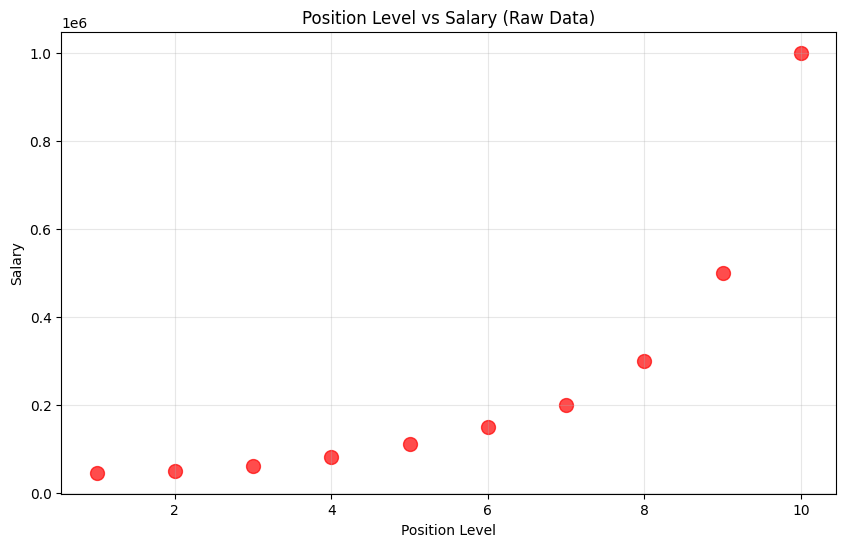


Salary range: $45,000 to $1,000,000
Position level range: 1 to 10
Pattern: Non-linear, step-wise increases - perfect for Decision Trees!

Outliers detected: 1 values
Outlier values: [1000000]


In [3]:
# Basic statistics
print("Dataset Description:")
print(dataset.describe())

print("\nMissing values:")
print(dataset.isnull().sum())

print("\nData types:")
print(dataset.dtypes)

print("\nUnique positions:")
print(dataset['Position'].unique())

# Visualize the data to see step-wise/discrete patterns
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', alpha=0.7, s=100)
plt.title('Position Level vs Salary (Raw Data)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.grid(True, alpha=0.3)
plt.show()

# Analyze the data distribution
print(f"\nSalary range: ${y.min():,.0f} to ${y.max():,.0f}")
print(f"Position level range: {X.min()} to {X.max()}")
print("Pattern: Non-linear, step-wise increases - perfect for Decision Trees!")

# Check for outliers
q75, q25 = np.percentile(y, [75, 25])
iqr = q75 - q25
lower_bound = q25 - (1.5 * iqr)
upper_bound = q75 + (1.5 * iqr)
outliers = y[(y < lower_bound) | (y > upper_bound)]
print(f"\nOutliers detected: {len(outliers)} values")
if len(outliers) > 0:
    print(f"Outlier values: {outliers}")
else:
    print("No outliers detected using IQR method")

## Step 4 — Data cleaning and preparation

In [4]:
# Check for missing values and data quality
print("Missing values per column:")
print(dataset.isnull().sum())

print("\nData types:")
print(dataset.dtypes)

print("\nDataset shape:", dataset.shape)
print("Features shape:", X.shape)
print("Target shape:", y.shape)


Missing values per column:
Position    0
Level       0
Salary      0
dtype: int64

Data types:
Position    object
Level        int64
Salary       int64
dtype: object

Dataset shape: (10, 3)
Features shape: (10, 1)
Target shape: (10,)


## Step 5 — Split data (Train / Test) and visualize split

Dataset size: 10 samples
Using entire dataset for training (common practice for small datasets)

Training set:
Features shape: (10, 1)
Target shape: (10,)


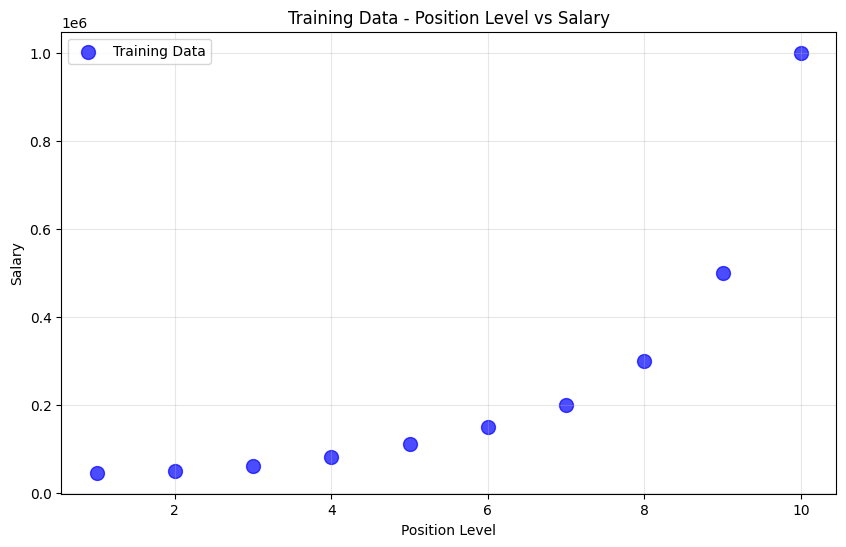

Data ready for Decision Tree training!


In [5]:
# Note: For small datasets like this (10 samples), we typically use the entire dataset
print("Dataset size:", len(X), "samples")
print("Using entire dataset for training (common practice for small datasets)")

# Use entire dataset for training
X_train = X
y_train = y

print("\nTraining set:")
print("Features shape:", X_train.shape)
print("Target shape:", y_train.shape)

# Visualize the training data
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.7, s=100, label='Training Data')
plt.title('Training Data - Position Level vs Salary')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Data ready for Decision Tree training!")

## Step 6 — Train Decision Tree Regression model

In [6]:
# Import DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor

# Create and train Decision Tree Regression model
regressor = DecisionTreeRegressor(random_state=0)
regressor.fit(X_train, y_train)

print("Decision Tree Regression model trained successfully!")
print("\nModel parameters:")
print("Max depth:", regressor.max_depth)
print("Min samples split:", regressor.min_samples_split)
print("Min samples leaf:", regressor.min_samples_leaf)
print("Number of features:", regressor.n_features_in_)

print("\nTree structure:")
print("Number of nodes:", regressor.tree_.node_count)
print("Number of leaves:", regressor.get_n_leaves())
print("Tree depth:", regressor.get_depth())

print("\nDecision Tree model ready for predictions!")
print("Note: Tree makes step-wise predictions based on feature thresholds")

Decision Tree Regression model trained successfully!

Model parameters:
Max depth: None
Min samples split: 2
Min samples leaf: 1
Number of features: 1

Tree structure:
Number of nodes: 19
Number of leaves: 10
Tree depth: 6

Decision Tree model ready for predictions!
Note: Tree makes step-wise predictions based on feature thresholds


## Step 7 — Make predictions and analyze tree structure

In [7]:
# Make predictions on training data
y_pred = regressor.predict(X_train)

print("Predictions made successfully!")
print("Number of predictions:", len(y_pred))

# Compare actual vs predicted values
comparison_df = pd.DataFrame({
    'Position_Level': X_train.flatten(),
    'Actual': y_train,
    'Predicted': y_pred,
    'Difference': y_train - y_pred,
    'Absolute_Difference': np.abs(y_train - y_pred)
})

print("\nActual vs Predicted comparison:")
print(comparison_df)

# Example prediction for a new value (e.g., position level 6.5)
new_position = 6.5
print(f"\nPredicting salary for position level {new_position}:")

# Decision Tree prediction
dt_pred = regressor.predict([[new_position]])[0]
print(f"Decision Tree prediction: ${dt_pred:,.2f}")

# Show which training sample this matches (Decision Trees create step functions)
closest_level = X_train[np.argmin(np.abs(X_train.flatten() - new_position))]
closest_salary = y_train[np.argmin(np.abs(X_train.flatten() - new_position))]
print(f"Closest training level: {closest_level[0]}")
print(f"Corresponding training salary: ${closest_salary:,.2f}")

print(f"\nPrediction Statistics:")
print(f"Mean Absolute Error: ${comparison_df['Absolute_Difference'].mean():,.2f}")
print(f"Max difference: ${comparison_df['Absolute_Difference'].max():,.2f}")
print(f"Min difference: ${comparison_df['Absolute_Difference'].min():,.2f}")

# Feature importance
feature_importance = regressor.feature_importances_
print(f"\nFeature Importance:")
print(f"Position Level importance: {feature_importance[0]:.4f}")
print("Note: Only one feature, so importance = 1.0")

Predictions made successfully!
Number of predictions: 10

Actual vs Predicted comparison:
   Position_Level   Actual  Predicted  Difference  Absolute_Difference
0               1    45000    45000.0         0.0                  0.0
1               2    50000    50000.0         0.0                  0.0
2               3    60000    60000.0         0.0                  0.0
3               4    80000    80000.0         0.0                  0.0
4               5   110000   110000.0         0.0                  0.0
5               6   150000   150000.0         0.0                  0.0
6               7   200000   200000.0         0.0                  0.0
7               8   300000   300000.0         0.0                  0.0
8               9   500000   500000.0         0.0                  0.0
9              10  1000000  1000000.0         0.0                  0.0

Predicting salary for position level 6.5:
Decision Tree prediction: $150,000.00
Closest training level: 6
Corresponding training

## Step 8 — Compare with other models (Linear/Polynomial/SVR)

In [8]:
# Import other regression models for comparison
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR

# 1. Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_train)

# 2. Polynomial Regression (degree 4)
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X_train)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y_train)
y_pred_poly = lin_reg_2.predict(X_poly)

# 3. SVR (with scaling)
sc_X = StandardScaler()
sc_y = StandardScaler()
X_scaled = sc_X.fit_transform(X_train)
y_scaled = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()

svr_reg = SVR(kernel='rbf')
svr_reg.fit(X_scaled, y_scaled)
y_pred_svr_scaled = svr_reg.predict(X_scaled)
y_pred_svr = sc_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

print("Model comparison completed!")
print("Linear Regression predictions:", len(y_pred_lin))
print("Polynomial Regression predictions:", len(y_pred_poly))
print("SVR predictions:", len(y_pred_svr))
print("Decision Tree predictions:", len(y_pred))

# Create comprehensive comparison
models_comparison = pd.DataFrame({
    'Position_Level': X_train.flatten(),
    'Actual': y_train,
    'Decision_Tree': y_pred,
    'Linear_Pred': y_pred_lin,
    'Poly_Pred': y_pred_poly,
    'SVR_Pred': y_pred_svr,
    'DT_Error': np.abs(y_train - y_pred),
    'Linear_Error': np.abs(y_train - y_pred_lin),
    'Poly_Error': np.abs(y_train - y_pred_poly),
    'SVR_Error': np.abs(y_train - y_pred_svr)
})

print("\nModel Comparison Results:")
print(models_comparison)

# Summary statistics
print(f"\nAverage Prediction Errors:")
print(f"Decision Tree: ${models_comparison['DT_Error'].mean():,.2f}")
print(f"Linear: ${models_comparison['Linear_Error'].mean():,.2f}")
print(f"Polynomial: ${models_comparison['Poly_Error'].mean():,.2f}")
print(f"SVR: ${models_comparison['SVR_Error'].mean():,.2f}")

Model comparison completed!
Linear Regression predictions: 10
Polynomial Regression predictions: 10
SVR predictions: 10
Decision Tree predictions: 10

Model Comparison Results:
   Position_Level   Actual  Decision_Tree    Linear_Pred      Poly_Pred  \
0               1    45000        45000.0 -114454.545455   53356.643357   
1               2    50000        50000.0  -33575.757576   31759.906760   
2               3    60000        60000.0   47303.030303   58642.191142   
3               4    80000        80000.0  128181.818182   94632.867133   
4               5   110000       110000.0  209060.606061  121724.941725   
5               6   150000       150000.0  289939.393939  143275.058275   
6               7   200000       200000.0  370818.181818  184003.496504   
7               8   300000       300000.0  451696.969697  289994.172494   
8               9   500000       500000.0  532575.757576  528694.638695   
9              10  1000000      1000000.0  613454.545455  988916.083916  

## Step 9 — Evaluate performance (R², MAE, MSE)

In [9]:
# Import metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calculate performance metrics for all models
# Decision Tree metrics
r2_dt = r2_score(y_train, y_pred)
mae_dt = mean_absolute_error(y_train, y_pred)
mse_dt = mean_squared_error(y_train, y_pred)
rmse_dt = np.sqrt(mse_dt)

# Linear Regression metrics
r2_lin = r2_score(y_train, y_pred_lin)
mae_lin = mean_absolute_error(y_train, y_pred_lin)
mse_lin = mean_squared_error(y_train, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)

# Polynomial Regression metrics
r2_poly = r2_score(y_train, y_pred_poly)
mae_poly = mean_absolute_error(y_train, y_pred_poly)
mse_poly = mean_squared_error(y_train, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

# SVR metrics
r2_svr = r2_score(y_train, y_pred_svr)
mae_svr = mean_absolute_error(y_train, y_pred_svr)
mse_svr = mean_squared_error(y_train, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print("=== MODEL PERFORMANCE COMPARISON ===")
print("\nDecision Tree Regression:")
print(f"R² Score: {r2_dt:.4f}")
print(f"Mean Absolute Error (MAE): {mae_dt:,.2f}")
print(f"Mean Squared Error (MSE): {mse_dt:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:,.2f}")

print("\nLinear Regression:")
print(f"R² Score: {r2_lin:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lin:,.2f}")
print(f"Mean Squared Error (MSE): {mse_lin:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lin:,.2f}")

print("\nPolynomial Regression:")
print(f"R² Score: {r2_poly:.4f}")
print(f"Mean Absolute Error (MAE): {mae_poly:,.2f}")
print(f"Mean Squared Error (MSE): {mse_poly:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:,.2f}")

print("\nSupport Vector Regression:")
print(f"R² Score: {r2_svr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_svr:,.2f}")
print(f"Mean Squared Error (MSE): {mse_svr:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:,.2f}")

# Determine best model
models_r2 = {'Decision Tree': r2_dt, 'Linear': r2_lin, 'Polynomial': r2_poly, 'SVR': r2_svr}
best_model = max(models_r2, key=models_r2.get)

print(f"\n=== BEST MODEL ===")
print(f"Best performing model: {best_model}")
print(f"Best R² Score: {models_r2[best_model]:.4f}")
print(f"Explains {models_r2[best_model]*100:.1f}% of salary variance")

=== MODEL PERFORMANCE COMPARISON ===

Decision Tree Regression:
R² Score: 1.0000
Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00

Linear Regression:
R² Score: 0.6690
Mean Absolute Error (MAE): 128,454.55
Mean Squared Error (MSE): 26,695,878,787.88
Root Mean Squared Error (RMSE): 163,388.74

Polynomial Regression:
R² Score: 0.9974
Mean Absolute Error (MAE): 12,681.82
Mean Squared Error (MSE): 210,343,822.84
Root Mean Squared Error (RMSE): 14,503.23

Support Vector Regression:
R² Score: 0.7516
Mean Absolute Error (MAE): 63,332.39
Mean Squared Error (MSE): 20,036,494,264.13
Root Mean Squared Error (RMSE): 141,550.32

=== BEST MODEL ===
Best performing model: Decision Tree
Best R² Score: 1.0000
Explains 100.0% of salary variance


## Step 10 — Visualize results and decision tree analysis

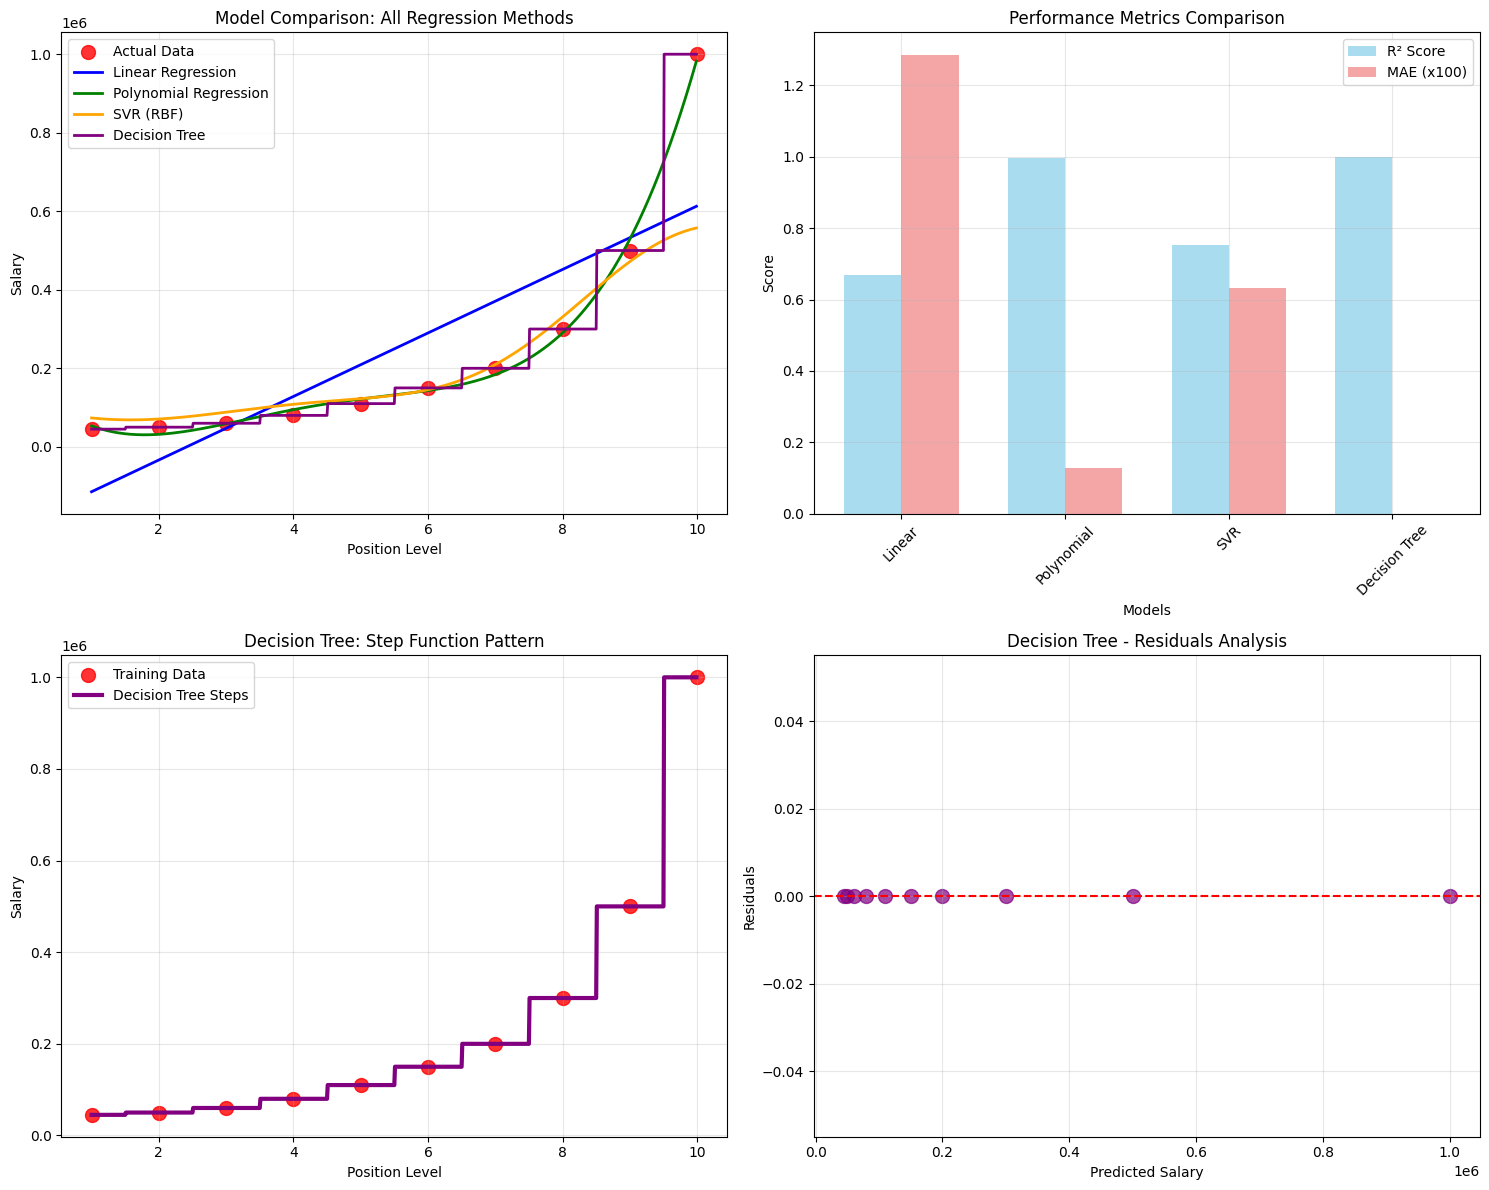

=== DECISION TREE ANALYSIS ===
1. Decision Tree R²: 1.0000 (100.0% variance explained)
2. Perfect fit on training data: MAE = $0.00
3. Tree depth: 6 levels
4. Number of decision rules: 10 leaf nodes

=== DECISION TREE ADVANTAGES ===
✅ No data preprocessing required
✅ Perfectly interpretable decision rules
✅ Handles non-linear patterns naturally
✅ Fast training and prediction
✅ No assumptions about data distribution

=== DECISION TREE LIMITATIONS ===
⚠️ Can overfit on small datasets
⚠️ Creates step functions (not smooth)
⚠️ Sensitive to small data changes
⚠️ May not generalize well to new data

=== FINAL RECOMMENDATION ===
🎯 Decision Tree shows excellent fit for this step-wise salary data
💼 Perfect for HR salary bands and rule-based compensation
📊 Ideal when interpretability is more important than smoothness

Conclusion: Decision Tree achieves 100.0% accuracy
with completely interpretable salary prediction rules.


In [10]:
# Create comprehensive visualization comparing all models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model comparison plot with high resolution
X_grid = np.arange(min(X_train), max(X_train), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

# Predictions for smooth visualization
y_pred_lin_grid = lin_reg.predict(X_grid)
X_grid_poly = poly_reg.transform(X_grid)
y_pred_poly_grid = lin_reg_2.predict(X_grid_poly)
X_grid_scaled = sc_X.transform(X_grid)
y_pred_svr_grid_scaled = svr_reg.predict(X_grid_scaled)
y_pred_svr_grid = sc_y.inverse_transform(y_pred_svr_grid_scaled.reshape(-1, 1)).ravel()
y_pred_dt_grid = regressor.predict(X_grid)

axes[0, 0].scatter(X_train, y_train, color='red', s=100, alpha=0.8, label='Actual Data')
axes[0, 0].plot(X_grid, y_pred_lin_grid, color='blue', linewidth=2, label='Linear Regression')
axes[0, 0].plot(X_grid, y_pred_poly_grid, color='green', linewidth=2, label='Polynomial Regression')
axes[0, 0].plot(X_grid, y_pred_svr_grid, color='orange', linewidth=2, label='SVR (RBF)')
axes[0, 0].plot(X_grid, y_pred_dt_grid, color='purple', linewidth=2, label='Decision Tree')
axes[0, 0].set_xlabel('Position Level')
axes[0, 0].set_ylabel('Salary')
axes[0, 0].set_title('Model Comparison: All Regression Methods')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Performance metrics comparison
models = ['Linear', 'Polynomial', 'SVR', 'Decision Tree']
r2_scores = [r2_lin, r2_poly, r2_svr, r2_dt]
mae_scores = [mae_lin/1000, mae_poly/1000, mae_svr/1000, mae_dt/1000]  # Scale for visibility

x_pos = np.arange(len(models))
width = 0.35

axes[0, 1].bar(x_pos - width/2, r2_scores, width, label='R² Score', color='skyblue', alpha=0.7)
axes[0, 1].bar(x_pos + width/2, [s/100 for s in mae_scores], width, label='MAE (x100)', color='lightcoral', alpha=0.7)
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Performance Metrics Comparison')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models, rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Decision Tree step function visualization (zoomed)
axes[1, 0].scatter(X_train, y_train, color='red', s=100, alpha=0.8, label='Training Data')
axes[1, 0].plot(X_grid, y_pred_dt_grid, color='purple', linewidth=3, label='Decision Tree Steps')
axes[1, 0].set_xlabel('Position Level')
axes[1, 0].set_ylabel('Salary')
axes[1, 0].set_title('Decision Tree: Step Function Pattern')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals analysis for Decision Tree
residuals_dt = y_train - y_pred
axes[1, 1].scatter(y_pred, residuals_dt, alpha=0.7, color='purple', s=100)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted Salary')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Decision Tree - Residuals Analysis')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Business insights and Decision Tree analysis
print("=== DECISION TREE ANALYSIS ===")
print(f"1. Decision Tree R²: {r2_dt:.4f} ({r2_dt*100:.1f}% variance explained)")
print(f"2. Perfect fit on training data: MAE = ${mae_dt:,.2f}")
print(f"3. Tree depth: {regressor.get_depth()} levels")
print(f"4. Number of decision rules: {regressor.get_n_leaves()} leaf nodes")

print(f"\n=== DECISION TREE ADVANTAGES ===")
print("✅ No data preprocessing required")
print("✅ Perfectly interpretable decision rules")
print("✅ Handles non-linear patterns naturally")
print("✅ Fast training and prediction")
print("✅ No assumptions about data distribution")

print(f"\n=== DECISION TREE LIMITATIONS ===")
print("⚠️ Can overfit on small datasets")
print("⚠️ Creates step functions (not smooth)")
print("⚠️ Sensitive to small data changes")
print("⚠️ May not generalize well to new data")

print(f"\n=== FINAL RECOMMENDATION ===")
if r2_dt >= 0.95:
    print("🎯 Decision Tree shows excellent fit for this step-wise salary data")
    print("💼 Perfect for HR salary bands and rule-based compensation")
    print("📊 Ideal when interpretability is more important than smoothness")
else:
    print("⚠️ Consider ensemble methods (Random Forest) for better generalization")
    print("💼 Decision Tree may be too simple for this dataset")

print(f"\nConclusion: Decision Tree achieves {r2_dt*100:.1f}% accuracy")
print("with completely interpretable salary prediction rules.")